In [1]:
import numpy as np
import pandas as pd
import scipy
import matplotlib.pyplot as plt

In [7]:
rng = np.random.default_rng(12345)

n = 100_000
w = rng.uniform(3, 5, size=n)
t0 = -rng.uniform(0, w)
# t0 = scipy.stats.triang(1, loc=-w, scale=w).rvs()
# t0 = scipy.stats.beta.rvs(a=0.7, b=1, loc=-w, scale=w)
# t0=-2
assert all(t0 + w >= 0)

<Axes: >

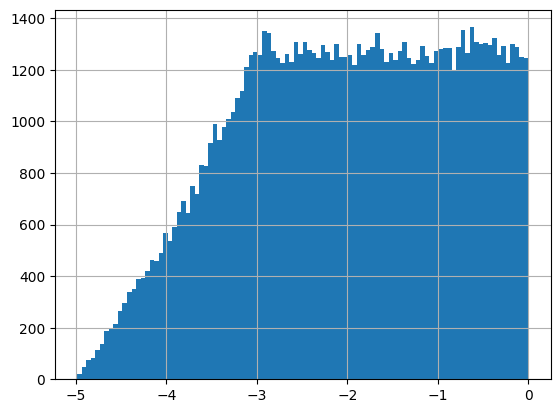

In [8]:
prev_t = pd.Series(t0)
prev_t.hist(bins=100)

<Axes: >

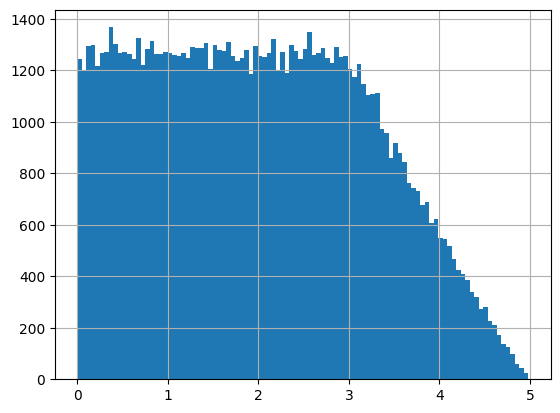

In [9]:
t1 = t0 + w
next_t = pd.Series(t1)
next_t.hist(bins=100)

<Axes: >

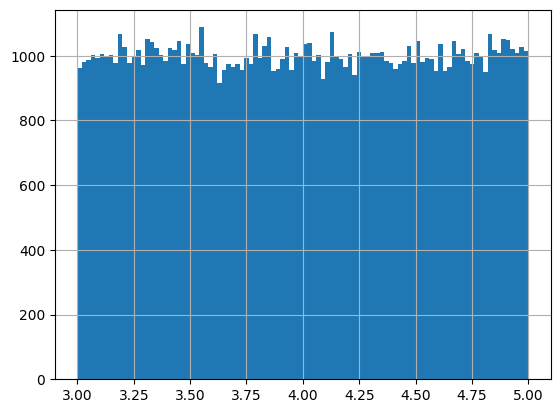

In [200]:
waiting = pd.Series(t1 - t0)
waiting.hist(bins=100)

<Axes: >

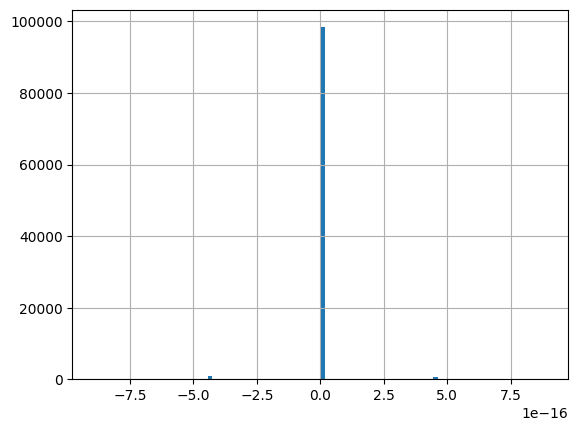

In [196]:
(waiting - w).hist(bins=100)

<Axes: >

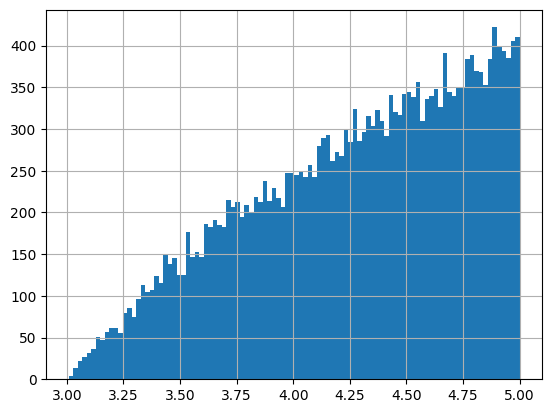

In [274]:
# The waiting time among simulants with test dates more than X years
# ago, with X>=3, looks approximately triangularly distributed: The
# density is 0 at X and increases to a maximum at 5.
waiting.loc[(-6 < prev_t) & (prev_t < -3)].hist(bins=100)

<Axes: >

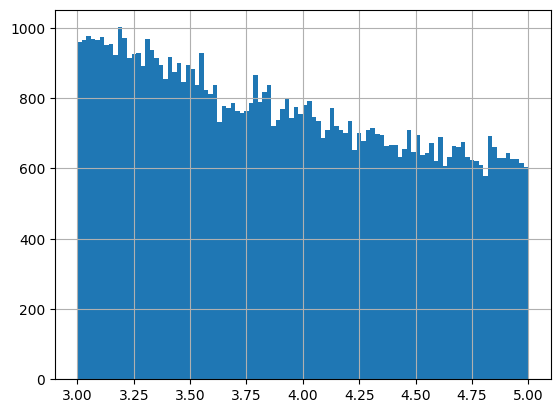

In [ ]:
# The waiting time among simulants with recent test dates is not uniform
# -- it's more likely to be near 3 years than near 5 years. It looks
# like if I subset to any interval in this range, the distribution stays
# the same. I think the downward slope in the density function is
# necessary to get a uniform distribution when mixed with the
# distribution of waiting times among those with dates more than 3 years
# ago.
waiting.loc[(-3 < prev_t) & (prev_t < 0)].hist(bins=100)

In [116]:
t1

array([0.38498184, 2.06728791, 4.11564851, ..., 0.55488167, 0.77464431,
       0.42616875])

In [117]:
t0

array([-3.0696902 , -1.56622877, -0.4790824 , ..., -3.04966595,
       -3.78580589, -3.03390505])

In [118]:
w

array([3.45467204, 3.63351668, 4.59473091, ..., 3.60454762, 4.5604502 ,
       3.4600738 ])

In [101]:
rng=np.random.default_rng(45678)

pop_size = 1_000_000

pop = pd.DataFrame(
    {'prev_test_time': -rng.integers(1, 11, size=pop_size),
    #  'next_test_time': pd.NA,
     }
).rename_axis('simulant_id')

pop['tested'] = False

pop

,prev_test_time,tested
simulant_id,,
0,-1,False
1,-8,False
2,-2,False
3,-5,False
4,-10,False
...,...,...
999995,-9,False
999996,-7,False
999997,-3,False


In [100]:
current_time = 0

record = []

def take_step(pop, current_time, rng):
    # Check eligibility
    k = current_time - pop['prev_test_time']
    # print(current_time)
    # print(k)
    eligible = (~pop['tested']) & (k >= 6)
    prob = 1 / (11 - k.loc[eligible])
    # print(prob)
    give_test = rng.uniform(size=eligible.sum()) < prob
    test_now = pd.Series(False, index=pop.index)
    test_now.loc[eligible] = give_test
    pop.loc[test_now, 'tested'] = True
    record.append(locals())
    return test_now

take_step(pop, current_time, rng)

simulant_id
0         False
1         False
2         False
3         False
4          True
          ...  
999995    False
999996    False
999997    False
999998    False
999999    False
Length: 1000000, dtype: bool

In [102]:
rng=np.random.default_rng(98765)

current_time = 0
record = []
next_test_time = pd.Series(pd.NA, index=pop.index)
while next_test_time.isna().any():
    test_now = take_step(pop, current_time, rng)
    next_test_time.loc[test_now] = current_time
    current_time += 1

next_test_time

simulant_id
0         9
1         0
2         7
3         5
4         0
         ..
999995    0
999996    3
999997    7
999998    7
999999    6
Length: 1000000, dtype: object

In [89]:
len(record)

2638

In [81]:
pd.concat([record[i]['k'] for i in range(len(record))], axis=1)

,prev_test_time,prev_test_time,prev_test_time,prev_test_time,prev_test_time,prev_test_time,prev_test_time,prev_test_time,prev_test_time,prev_test_time
simulant_id,,,,,,,,,,
0,1,2,3,4,5,6,7,8,9,10
1,8,9,10,11,12,13,14,15,16,17
2,2,3,4,5,6,7,8,9,10,11
3,5,6,7,8,9,10,11,12,13,14
4,10,11,12,13,14,15,16,17,18,19
...,...,...,...,...,...,...,...,...,...,...
99995,4,5,6,7,8,9,10,11,12,13
99996,8,9,10,11,12,13,14,15,16,17
99997,4,5,6,7,8,9,10,11,12,13


In [82]:
pd.concat([record[i]['prob'] for i in range(len(record))], axis=1)

,prev_test_time,prev_test_time,prev_test_time,prev_test_time,prev_test_time,prev_test_time,prev_test_time,prev_test_time,prev_test_time,prev_test_time
simulant_id,,,,,,,,,,
1,0.333333,0.5,1.0,inf,-1.000000,-0.500000,-0.333333,-0.250000,-0.200000,-0.166667
4,1.000000,inf,-1.0,-0.5,-0.333333,-0.250000,-0.200000,-0.166667,-0.142857,-0.125000
5,1.000000,inf,-1.0,-0.5,-0.333333,-0.250000,-0.200000,-0.166667,-0.142857,-0.125000
6,0.500000,1.0,inf,-1.0,-0.500000,-0.333333,-0.250000,-0.200000,-0.166667,-0.142857
7,0.500000,1.0,inf,-1.0,-0.500000,-0.333333,-0.250000,-0.200000,-0.166667,-0.142857
...,...,...,...,...,...,...,...,...,...,...
99918,NaN,NaN,NaN,NaN,NaN,0.200000,0.250000,0.333333,0.500000,1.000000
99930,NaN,NaN,NaN,NaN,NaN,0.200000,0.250000,0.333333,0.500000,1.000000
99947,NaN,NaN,NaN,NaN,NaN,0.200000,0.250000,0.333333,0.500000,1.000000


In [83]:
record[0].keys()

dict_keys(['pop', 'current_time', 'rng', 'k', 'eligible', 'prob', 'give_test', 'test_now'])

In [105]:
(next_test_time - pop.prev_test_time).value_counts()

10    329385
9     228258
8     177372
7     145264
6     119721
Name: count, dtype: int64

<Axes: >

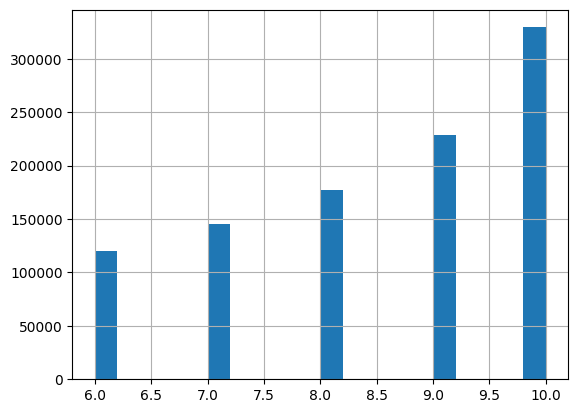

In [107]:
(next_test_time - pop.prev_test_time).hist(bins=20)

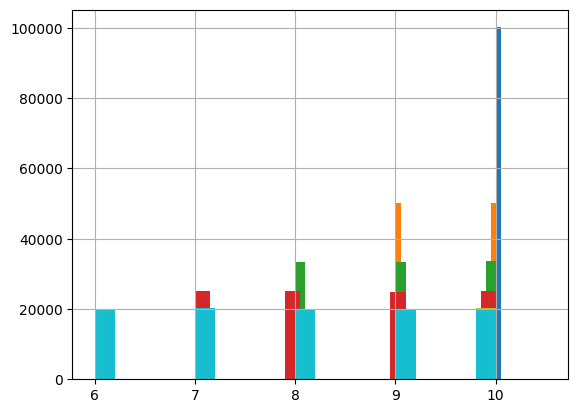

In [ ]:
# The overall distribution of waiting times in the above plot is a
# mixture of uniform distributions, one for each value of the previous
# test date, as follows:
df = pop.join(next_test_time.rename('next')).assign(
    waiting = lambda df: df['next'] - df['prev_test_time']
)

for h in range(-10, 0):
    df.query("prev_test_time == @h").waiting.hist(bins=20)


<Axes: >

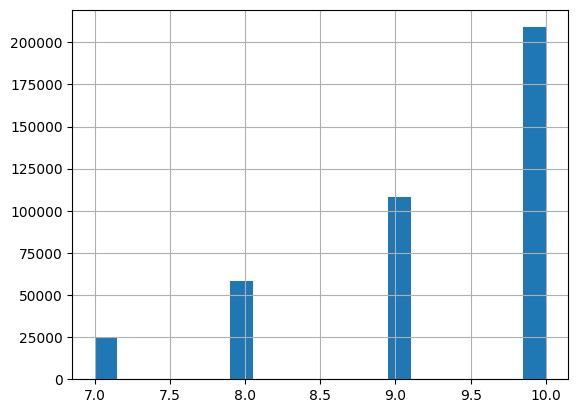

In [279]:
df.query("prev_test_time < -6").waiting.hist(bins=20)

<Axes: >

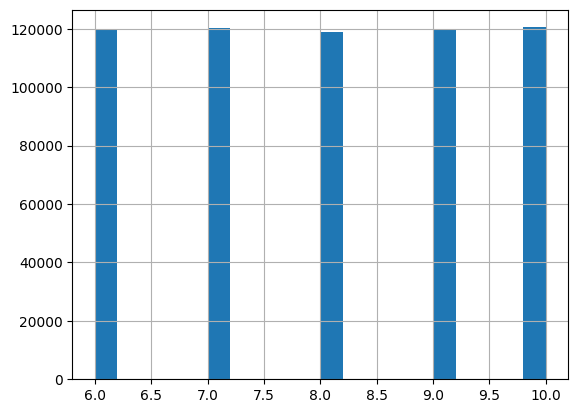

In [ ]:
# The waiting time among simulants with test dates at most 3 years ago
# is uniformly distributed. It looks like if I subset to any test date
# interval in this range, it remains uniform.
df.query("prev_test_time >= -4").waiting.hist(bins=20)

In [104]:
next_test_time.value_counts()

0    228468
1    148581
2    118401
3    105071
5     99716
4     99138
6     80140
7     60202
8     40277
9     20006
Name: count, dtype: int64

<Axes: >

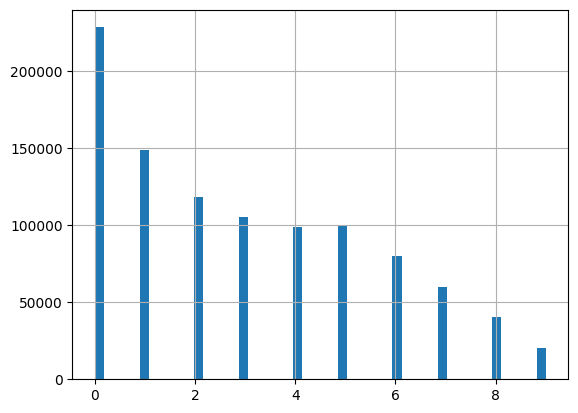

In [103]:
next_test_time.hist(bins=50)

In [71]:
pop.loc[test_now]

,prev_test_time
simulant_id,
0,-1
2,-2
8,-2
10,-2
11,-2
...,...
99966,-2
99972,-1
99980,-2


In [72]:
test_now

simulant_id
0         True
1        False
2         True
3        False
4        False
         ...  
99995    False
99996    False
99997    False
99998    False
99999    False
Length: 100000, dtype: bool